In [1]:
# ============================================================
# Step 1: Setup Drive, Folders, and Paths
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Main root
OIL_SPILL_ROOT = Path("/content/drive/MyDrive/Oil Spill")

# Input folder from Best Detection Model
BEST_DETECTION_DIR = OIL_SPILL_ROOT / "Best Detection Model"
BEST_DETECTION_PROCESSED_DIR = BEST_DETECTION_DIR / "processed"

# Output folder for LSTM trajectory part
TRAJECTORY_DIR = OIL_SPILL_ROOT / "04_Trajectory_LSTM"

NOTEBOOK_DIR = TRAJECTORY_DIR / "notebooks"
DATA_DIR = TRAJECTORY_DIR / "data"
EXTRACTED_DIR = DATA_DIR / "extracted"
GENERATED_DIR = DATA_DIR / "generated"
SPLITS_DIR = DATA_DIR / "splits"
SEQUENCES_DIR = DATA_DIR / "sequences"

SCALER_DIR = TRAJECTORY_DIR / "scalers"
MODEL_DIR = TRAJECTORY_DIR / "models"
RESULT_DIR = TRAJECTORY_DIR / "results"
PLOT_DIR = TRAJECTORY_DIR / "plots"
LOG_DIR = TRAJECTORY_DIR / "logs"

folders = [
    NOTEBOOK_DIR,
    DATA_DIR,
    EXTRACTED_DIR,
    GENERATED_DIR,
    SPLITS_DIR,
    SEQUENCES_DIR,
    SCALER_DIR,
    MODEL_DIR,
    RESULT_DIR,
    PLOT_DIR,
    LOG_DIR
]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)

print("Oil Spill root:", OIL_SPILL_ROOT)
print("Detection processed dir:", BEST_DETECTION_PROCESSED_DIR)
print("Detection processed exists:", BEST_DETECTION_PROCESSED_DIR.exists())

for split in ["train", "valid", "test"]:
    img_dir = BEST_DETECTION_PROCESSED_DIR / split / "images"
    mask_dir = BEST_DETECTION_PROCESSED_DIR / split / "masks"

    print(f"\n{split.upper()}")
    print("Images folder:", img_dir)
    print("Images exists:", img_dir.exists())
    print("Masks folder :", mask_dir)
    print("Masks exists :", mask_dir.exists())

Mounted at /content/drive
Oil Spill root: /content/drive/MyDrive/Oil Spill
Detection processed dir: /content/drive/MyDrive/Oil Spill/Best Detection Model/processed
Detection processed exists: True

TRAIN
Images folder: /content/drive/MyDrive/Oil Spill/Best Detection Model/processed/train/images
Images exists: True
Masks folder : /content/drive/MyDrive/Oil Spill/Best Detection Model/processed/train/masks
Masks exists : True

VALID
Images folder: /content/drive/MyDrive/Oil Spill/Best Detection Model/processed/valid/images
Images exists: True
Masks folder : /content/drive/MyDrive/Oil Spill/Best Detection Model/processed/valid/masks
Masks exists : True

TEST
Images folder: /content/drive/MyDrive/Oil Spill/Best Detection Model/processed/test/images
Images exists: True
Masks folder : /content/drive/MyDrive/Oil Spill/Best Detection Model/processed/test/masks
Masks exists : True


In [2]:
# ============================================================
# Step 2: Count Images and Masks
# ============================================================

def count_files(folder, extensions):
    folder = Path(folder)

    if not folder.exists():
        return 0

    return len([
        f for f in folder.iterdir()
        if f.is_file() and f.suffix.lower() in extensions
    ])


count_rows = []

for split in ["train", "valid", "test"]:
    img_dir = BEST_DETECTION_PROCESSED_DIR / split / "images"
    mask_dir = BEST_DETECTION_PROCESSED_DIR / split / "masks"

    image_count = count_files(img_dir, [".jpg", ".jpeg", ".png"])
    mask_count = count_files(mask_dir, [".png"])

    count_rows.append({
        "split": split,
        "image_count": image_count,
        "mask_count": mask_count
    })

count_df = pd.DataFrame(count_rows)

count_path = RESULT_DIR / "processed_image_mask_count_summary.csv"
count_df.to_csv(count_path, index=False)

print("Saved:", count_path)
count_df

Saved: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/results/processed_image_mask_count_summary.csv


,split,image_count,mask_count
0,train,2223,2223
1,valid,675,675
2,test,343,343


In [3]:
# ============================================================
# Step 3: Pair Images and Masks by Filename Stem
# ============================================================

def get_image_mask_pairs(split):
    img_dir = BEST_DETECTION_PROCESSED_DIR / split / "images"
    mask_dir = BEST_DETECTION_PROCESSED_DIR / split / "masks"

    image_map = {
        f.stem: f
        for f in img_dir.iterdir()
        if f.is_file() and f.suffix.lower() in [".jpg", ".jpeg", ".png"]
    }

    mask_map = {
        f.stem: f
        for f in mask_dir.iterdir()
        if f.is_file() and f.suffix.lower() == ".png"
    }

    paired_keys = sorted(set(image_map.keys()) & set(mask_map.keys()))

    pairs = []

    for key in paired_keys:
        pairs.append({
            "image_id": key,
            "split": split,
            "image_path": str(image_map[key]),
            "mask_path": str(mask_map[key])
        })

    missing_images = sorted(set(mask_map.keys()) - set(image_map.keys()))
    missing_masks = sorted(set(image_map.keys()) - set(mask_map.keys()))

    print(f"\n{split.upper()} split")
    print("Paired samples:", len(pairs))
    print("Missing images:", len(missing_images))
    print("Missing masks:", len(missing_masks))

    return pairs, missing_images, missing_masks


all_pairs = []
pairing_issues = {}

for split in ["train", "valid", "test"]:
    pairs, missing_images, missing_masks = get_image_mask_pairs(split)
    all_pairs.extend(pairs)

    pairing_issues[split] = {
        "missing_images": missing_images,
        "missing_masks": missing_masks
    }

pairs_df = pd.DataFrame(all_pairs)

pairs_path = RESULT_DIR / "processed_image_mask_pairs.csv"
issues_path = RESULT_DIR / "processed_pairing_issues.json"

pairs_df.to_csv(pairs_path, index=False)

with open(issues_path, "w") as f:
    json.dump(pairing_issues, f, indent=2)

print("\nTotal paired samples:", len(pairs_df))
print("Saved pairs:", pairs_path)
print("Saved issues:", issues_path)

pairs_df.head()


TRAIN split
Paired samples: 2223
Missing images: 0
Missing masks: 0

VALID split
Paired samples: 675
Missing images: 0
Missing masks: 0

TEST split
Paired samples: 343
Missing images: 0
Missing masks: 0

Total paired samples: 3241
Saved pairs: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/results/processed_image_mask_pairs.csv
Saved issues: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/results/processed_pairing_issues.json


,image_id,split,image_path,mask_path
0,01_taylor_jpeg_jpg.rf.4a466016aec4913557fe9fe8...,train,/content/drive/MyDrive/Oil Spill/Best Detectio...,/content/drive/MyDrive/Oil Spill/Best Detectio...
1,037ff865416549-5af427762eb81_jpg.rf.3221140cc7...,train,/content/drive/MyDrive/Oil Spill/Best Detectio...,/content/drive/MyDrive/Oil Spill/Best Detectio...
2,037ff865416549-5af427762eb81_jpg.rf.9a2a79a7d2...,train,/content/drive/MyDrive/Oil Spill/Best Detectio...,/content/drive/MyDrive/Oil Spill/Best Detectio...
3,037ff865416549-5af427762eb81_jpg.rf.cb9ac01c9e...,train,/content/drive/MyDrive/Oil Spill/Best Detectio...,/content/drive/MyDrive/Oil Spill/Best Detectio...
4,0517-ABIGSPILL-02-GULF-COAST-ENVIRONMENT-OIL-S...,train,/content/drive/MyDrive/Oil Spill/Best Detectio...,/content/drive/MyDrive/Oil Spill/Best Detectio...


In [4]:
# ============================================================
# Step 4: Extract Mask Geometry Features
# ============================================================

def extract_mask_features(mask_path):
    mask_path = Path(mask_path)

    mask = Image.open(mask_path).convert("L")
    mask_np = np.array(mask)

    mask_height, mask_width = mask_np.shape
    total_pixels = int(mask_height * mask_width)

    # Binary oil mask
    binary_mask = (mask_np > 127).astype(np.uint8)

    area_pixels = int(binary_mask.sum())
    area_ratio = float(area_pixels / total_pixels) if total_pixels > 0 else 0.0

    # Empty mask case
    if area_pixels == 0:
        return {
            "mask_width": mask_width,
            "mask_height": mask_height,
            "area_pixels": 0,
            "area_ratio": 0.0,
            "centroid_x": np.nan,
            "centroid_y": np.nan,
            "centroid_x_norm": np.nan,
            "centroid_y_norm": np.nan,
            "bbox_x_min": np.nan,
            "bbox_y_min": np.nan,
            "bbox_x_max": np.nan,
            "bbox_y_max": np.nan,
            "bbox_width": 0,
            "bbox_height": 0,
            "bbox_area": 0,
            "bbox_area_ratio": 0.0,
            "is_empty_mask": True
        }

    ys, xs = np.where(binary_mask == 1)

    centroid_x = float(xs.mean())
    centroid_y = float(ys.mean())

    bbox_x_min = int(xs.min())
    bbox_x_max = int(xs.max())
    bbox_y_min = int(ys.min())
    bbox_y_max = int(ys.max())

    bbox_width = int(bbox_x_max - bbox_x_min + 1)
    bbox_height = int(bbox_y_max - bbox_y_min + 1)
    bbox_area = int(bbox_width * bbox_height)
    bbox_area_ratio = float(bbox_area / total_pixels) if total_pixels > 0 else 0.0

    return {
        "mask_width": mask_width,
        "mask_height": mask_height,
        "area_pixels": area_pixels,
        "area_ratio": area_ratio,
        "centroid_x": centroid_x,
        "centroid_y": centroid_y,
        "centroid_x_norm": float(centroid_x / mask_width),
        "centroid_y_norm": float(centroid_y / mask_height),
        "bbox_x_min": bbox_x_min,
        "bbox_y_min": bbox_y_min,
        "bbox_x_max": bbox_x_max,
        "bbox_y_max": bbox_y_max,
        "bbox_width": bbox_width,
        "bbox_height": bbox_height,
        "bbox_area": bbox_area,
        "bbox_area_ratio": bbox_area_ratio,
        "is_empty_mask": False
    }


feature_rows = []

for idx, row in pairs_df.iterrows():
    features = extract_mask_features(row["mask_path"])

    feature_rows.append({
        "sample_index": idx,
        "image_id": row["image_id"],
        "split": row["split"],
        "image_path": row["image_path"],
        "mask_path": row["mask_path"],
        **features
    })

mask_features_df = pd.DataFrame(feature_rows)

features_path = EXTRACTED_DIR / "trajectory_lados_mask_features.csv"
mask_features_df.to_csv(features_path, index=False)

print("Saved:", features_path)
print("Shape:", mask_features_df.shape)

mask_features_df.head()

Saved: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/data/extracted/trajectory_lados_mask_features.csv
Shape: (3241, 22)


,sample_index,image_id,split,image_path,mask_path,mask_width,mask_height,area_pixels,area_ratio,centroid_x,...,centroid_y_norm,bbox_x_min,bbox_y_min,bbox_x_max,bbox_y_max,bbox_width,bbox_height,bbox_area,bbox_area_ratio,is_empty_mask
0,0,01_taylor_jpeg_jpg.rf.4a466016aec4913557fe9fe8...,train,/content/drive/MyDrive/Oil Spill/Best Detectio...,/content/drive/MyDrive/Oil Spill/Best Detectio...,640,640,310131,0.757156,294.021175,...,0.603256,2.0,27.0,639.0,639.0,638,613,391094,0.954819,False
1,1,037ff865416549-5af427762eb81_jpg.rf.3221140cc7...,train,/content/drive/MyDrive/Oil Spill/Best Detectio...,/content/drive/MyDrive/Oil Spill/Best Detectio...,640,640,409600,1.000000,319.500000,...,0.499219,0.0,0.0,639.0,639.0,640,640,409600,1.000000,False
2,2,037ff865416549-5af427762eb81_jpg.rf.9a2a79a7d2...,train,/content/drive/MyDrive/Oil Spill/Best Detectio...,/content/drive/MyDrive/Oil Spill/Best Detectio...,640,640,409600,1.000000,319.500000,...,0.499219,0.0,0.0,639.0,639.0,640,640,409600,1.000000,False
3,3,037ff865416549-5af427762eb81_jpg.rf.cb9ac01c9e...,train,/content/drive/MyDrive/Oil Spill/Best Detectio...,/content/drive/MyDrive/Oil Spill/Best Detectio...,640,640,408638,0.997651,320.250845,...,0.499117,0.0,0.0,639.0,639.0,640,640,409600,1.000000,False
4,4,0517-ABIGSPILL-02-GULF-COAST-ENVIRONMENT-OIL-S...,train,/content/drive/MyDrive/Oil Spill/Best Detectio...,/content/drive/MyDrive/Oil Spill/Best Detectio...,640,640,0,0.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0.000000,True


In [5]:
# ============================================================
# Step 5: Create Mask Feature Summary by Split
# ============================================================

summary_rows = []

for split in ["train", "valid", "test"]:
    split_df = mask_features_df[mask_features_df["split"] == split]
    non_empty_df = split_df[split_df["is_empty_mask"] == False]

    summary_rows.append({
        "split": split,
        "total_samples": len(split_df),
        "non_empty_masks": len(non_empty_df),
        "empty_masks": int(split_df["is_empty_mask"].sum()),
        "empty_mask_ratio": float(split_df["is_empty_mask"].mean()) if len(split_df) > 0 else 0.0,
        "mean_area_pixels": float(non_empty_df["area_pixels"].mean()) if len(non_empty_df) > 0 else 0.0,
        "median_area_pixels": float(non_empty_df["area_pixels"].median()) if len(non_empty_df) > 0 else 0.0,
        "min_area_pixels": int(non_empty_df["area_pixels"].min()) if len(non_empty_df) > 0 else 0,
        "max_area_pixels": int(non_empty_df["area_pixels"].max()) if len(non_empty_df) > 0 else 0,
        "mean_area_ratio": float(non_empty_df["area_ratio"].mean()) if len(non_empty_df) > 0 else 0.0
    })

summary_df = pd.DataFrame(summary_rows)

summary_path = RESULT_DIR / "lados_mask_feature_summary.csv"
summary_df.to_csv(summary_path, index=False)

print("Saved:", summary_path)
summary_df

Saved: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/results/lados_mask_feature_summary.csv


,split,total_samples,non_empty_masks,empty_masks,empty_mask_ratio,mean_area_pixels,median_area_pixels,min_area_pixels,max_area_pixels,mean_area_ratio
0,train,2223,1331,892,0.401260,157655.308790,148784.0,67,409600,0.384901
1,valid,675,394,281,0.416296,163871.862944,157224.0,221,409600,0.400078
2,test,343,209,134,0.390671,171945.148325,166590.0,300,409600,0.419788


In [6]:
# ============================================================
# Step 6: Save Non-Empty Mask Feature Dataset
# ============================================================

non_empty_features_df = mask_features_df[
    mask_features_df["is_empty_mask"] == False
].copy()

non_empty_path = EXTRACTED_DIR / "trajectory_lados_non_empty_mask_features.csv"
non_empty_features_df.to_csv(non_empty_path, index=False)

print("Saved:", non_empty_path)
print("Total samples:", len(mask_features_df))
print("Non-empty samples:", len(non_empty_features_df))
print("Empty samples:", int(mask_features_df["is_empty_mask"].sum()))

non_empty_features_df.head()

Saved: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/data/extracted/trajectory_lados_non_empty_mask_features.csv
Total samples: 3241
Non-empty samples: 1934
Empty samples: 1307


,sample_index,image_id,split,image_path,mask_path,mask_width,mask_height,area_pixels,area_ratio,centroid_x,...,centroid_y_norm,bbox_x_min,bbox_y_min,bbox_x_max,bbox_y_max,bbox_width,bbox_height,bbox_area,bbox_area_ratio,is_empty_mask
0,0,01_taylor_jpeg_jpg.rf.4a466016aec4913557fe9fe8...,train,/content/drive/MyDrive/Oil Spill/Best Detectio...,/content/drive/MyDrive/Oil Spill/Best Detectio...,640,640,310131,0.757156,294.021175,...,0.603256,2.0,27.0,639.0,639.0,638,613,391094,0.954819,False
1,1,037ff865416549-5af427762eb81_jpg.rf.3221140cc7...,train,/content/drive/MyDrive/Oil Spill/Best Detectio...,/content/drive/MyDrive/Oil Spill/Best Detectio...,640,640,409600,1.000000,319.500000,...,0.499219,0.0,0.0,639.0,639.0,640,640,409600,1.000000,False
2,2,037ff865416549-5af427762eb81_jpg.rf.9a2a79a7d2...,train,/content/drive/MyDrive/Oil Spill/Best Detectio...,/content/drive/MyDrive/Oil Spill/Best Detectio...,640,640,409600,1.000000,319.500000,...,0.499219,0.0,0.0,639.0,639.0,640,640,409600,1.000000,False
3,3,037ff865416549-5af427762eb81_jpg.rf.cb9ac01c9e...,train,/content/drive/MyDrive/Oil Spill/Best Detectio...,/content/drive/MyDrive/Oil Spill/Best Detectio...,640,640,408638,0.997651,320.250845,...,0.499117,0.0,0.0,639.0,639.0,640,640,409600,1.000000,False
5,5,09581f43c02f20bbaef8383c3d82fd45_jpg.rf.318ce5...,train,/content/drive/MyDrive/Oil Spill/Best Detectio...,/content/drive/MyDrive/Oil Spill/Best Detectio...,640,640,409464,0.999668,319.605404,...,0.499138,0.0,0.0,639.0,639.0,640,640,409600,1.000000,False


In [12]:
# ============================================================
# Step 6B: Mask Quality Filtering for Trajectory Initialization
# ============================================================

quality_df = non_empty_features_df.copy()

# Quality flags
quality_df["is_tiny_mask"] = quality_df["area_pixels"] < 100
quality_df["is_near_full_mask"] = quality_df["area_ratio"] > 0.95
quality_df["is_valid_for_trajectory"] = (
    (quality_df["is_tiny_mask"] == False) &
    (quality_df["is_near_full_mask"] == False)
)

quality_summary = pd.DataFrame([
    {
        "total_non_empty_masks": len(quality_df),
        "tiny_masks_area_less_than_100": int(quality_df["is_tiny_mask"].sum()),
        "near_full_masks_area_ratio_above_0_95": int(quality_df["is_near_full_mask"].sum()),
        "valid_masks_for_trajectory": int(quality_df["is_valid_for_trajectory"].sum())
    }
])

quality_summary_path = RESULT_DIR / "lados_mask_quality_filter_summary.csv"
quality_summary.to_csv(quality_summary_path, index=False)

valid_trajectory_features_df = quality_df[
    quality_df["is_valid_for_trajectory"] == True
].copy()

valid_features_path = EXTRACTED_DIR / "trajectory_lados_valid_mask_features.csv"
valid_trajectory_features_df.to_csv(valid_features_path, index=False)

print("Saved quality summary:", quality_summary_path)
print("Saved valid trajectory features:", valid_features_path)

quality_summary

Saved quality summary: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/results/lados_mask_quality_filter_summary.csv
Saved valid trajectory features: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/data/extracted/trajectory_lados_valid_mask_features.csv


,total_non_empty_masks,tiny_masks_area_less_than_100,near_full_masks_area_ratio_above_0_95,valid_masks_for_trajectory
0,1934,1,138,1795


In [13]:
# ============================================================
# Step 6C: Valid Mask Count by Split
# ============================================================

valid_split_summary = (
    valid_trajectory_features_df
    .groupby("split")
    .agg(
        total_valid_masks=("image_id", "count"),
        mean_area_pixels=("area_pixels", "mean"),
        median_area_pixels=("area_pixels", "median"),
        min_area_pixels=("area_pixels", "min"),
        max_area_pixels=("area_pixels", "max"),
        mean_area_ratio=("area_ratio", "mean")
    )
    .reset_index()
)

valid_split_summary_path = RESULT_DIR / "lados_valid_mask_split_summary.csv"
valid_split_summary.to_csv(valid_split_summary_path, index=False)

print("Saved:", valid_split_summary_path)
valid_split_summary

Saved: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/results/lados_valid_mask_split_summary.csv


,split,total_valid_masks,mean_area_pixels,median_area_pixels,min_area_pixels,max_area_pixels,mean_area_ratio
0,test,190,148732.389474,136798.0,300,388268,0.363116
1,train,1235,138645.755466,130621.0,202,388463,0.338491
2,valid,370,148081.632432,141318.0,221,382856,0.361527


In [19]:
# ============================================================
# Step 6C: Valid Mask Count by Split
# ============================================================

valid_split_summary = (
    valid_trajectory_features_df
    .groupby("split")
    .agg(
        total_valid_masks=("image_id", "count"),
        mean_area_pixels=("area_pixels", "mean"),
        median_area_pixels=("area_pixels", "median"),
        min_area_pixels=("area_pixels", "min"),
        max_area_pixels=("area_pixels", "max"),
        mean_area_ratio=("area_ratio", "mean")
    )
    .reset_index()
)

valid_split_summary_path = RESULT_DIR / "lados_valid_mask_split_summary.csv"
valid_split_summary.to_csv(valid_split_summary_path, index=False)

print("Saved:", valid_split_summary_path)
valid_split_summary

Saved: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/results/lados_valid_mask_split_summary.csv


,split,total_valid_masks,mean_area_pixels,median_area_pixels,min_area_pixels,max_area_pixels,mean_area_ratio
0,test,190,148732.389474,136798.0,300,388268,0.363116
1,train,1235,138645.755466,130621.0,202,388463,0.338491
2,valid,370,148081.632432,141318.0,221,382856,0.361527


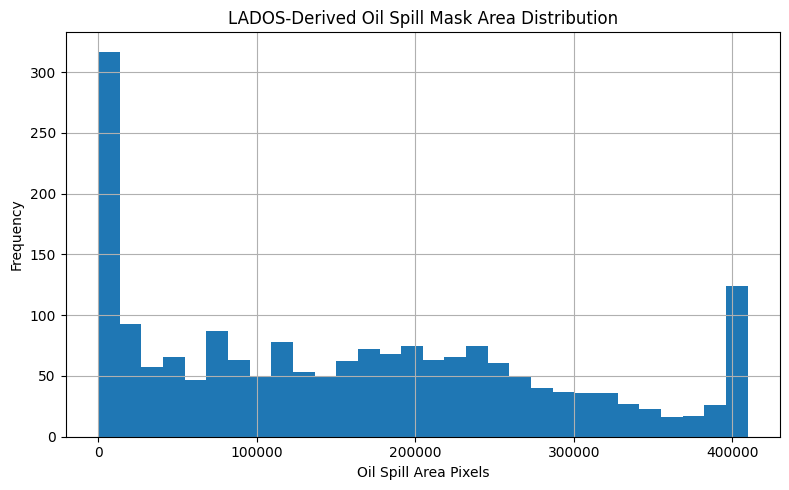

Saved: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/plots/lados_mask_area_distribution.png


In [20]:
# ============================================================
# Step 7: Plot Oil Spill Mask Area Distribution
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(non_empty_features_df["area_pixels"], bins=30)
plt.xlabel("Oil Spill Area Pixels")
plt.ylabel("Frequency")
plt.title("LADOS-Derived Oil Spill Mask Area Distribution")
plt.grid(True)
plt.tight_layout()

area_plot_path = PLOT_DIR / "lados_mask_area_distribution.png"
plt.savefig(area_plot_path, dpi=200)
plt.show()

print("Saved:", area_plot_path)

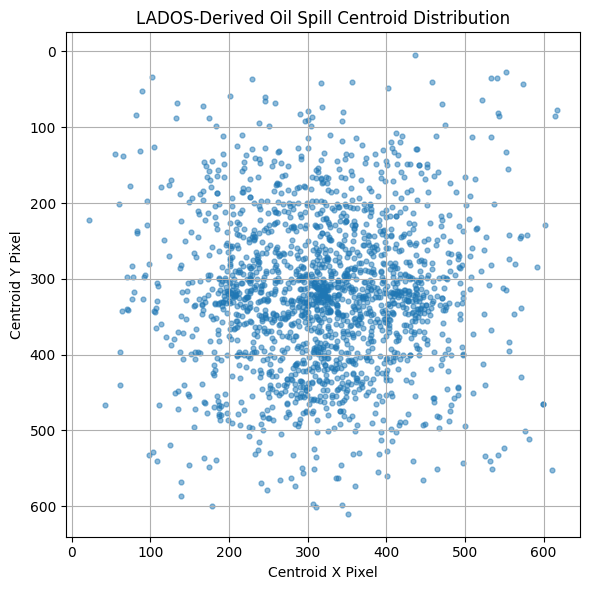

Saved: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/plots/lados_centroid_distribution.png


In [21]:
# ============================================================
# Step 8: Plot Oil Spill Centroid Distribution
# ============================================================

plt.figure(figsize=(6, 6))

plt.scatter(
    non_empty_features_df["centroid_x"],
    non_empty_features_df["centroid_y"],
    alpha=0.5,
    s=12
)

plt.gca().invert_yaxis()
plt.xlabel("Centroid X Pixel")
plt.ylabel("Centroid Y Pixel")
plt.title("LADOS-Derived Oil Spill Centroid Distribution")
plt.grid(True)
plt.tight_layout()

centroid_plot_path = PLOT_DIR / "lados_centroid_distribution.png"
plt.savefig(centroid_plot_path, dpi=200)
plt.show()

print("Saved:", centroid_plot_path)

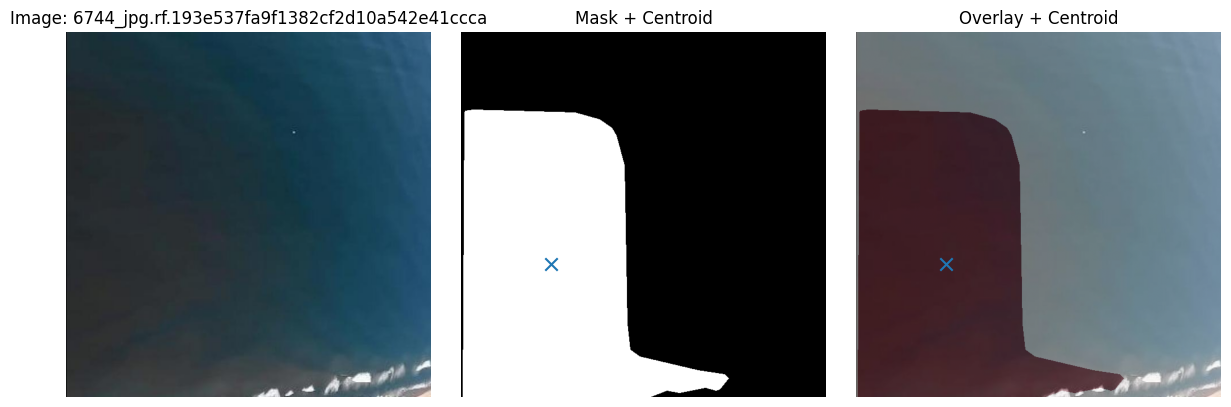

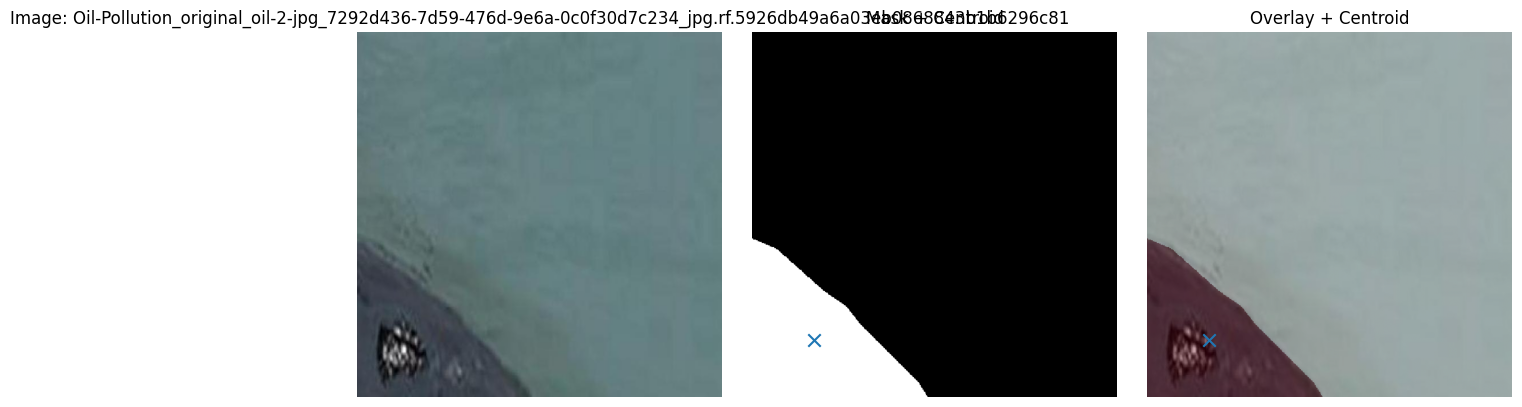

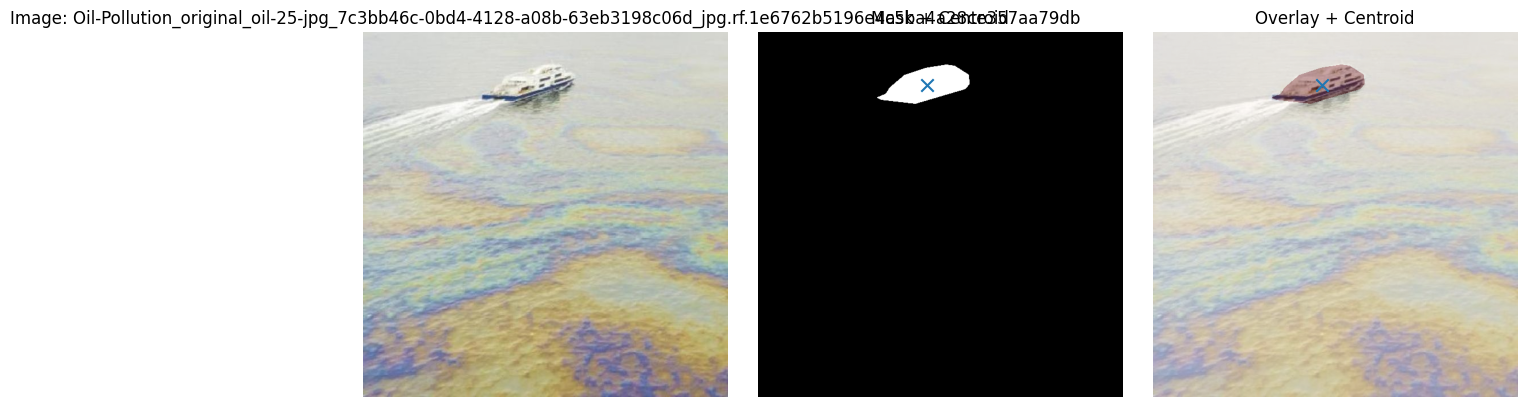

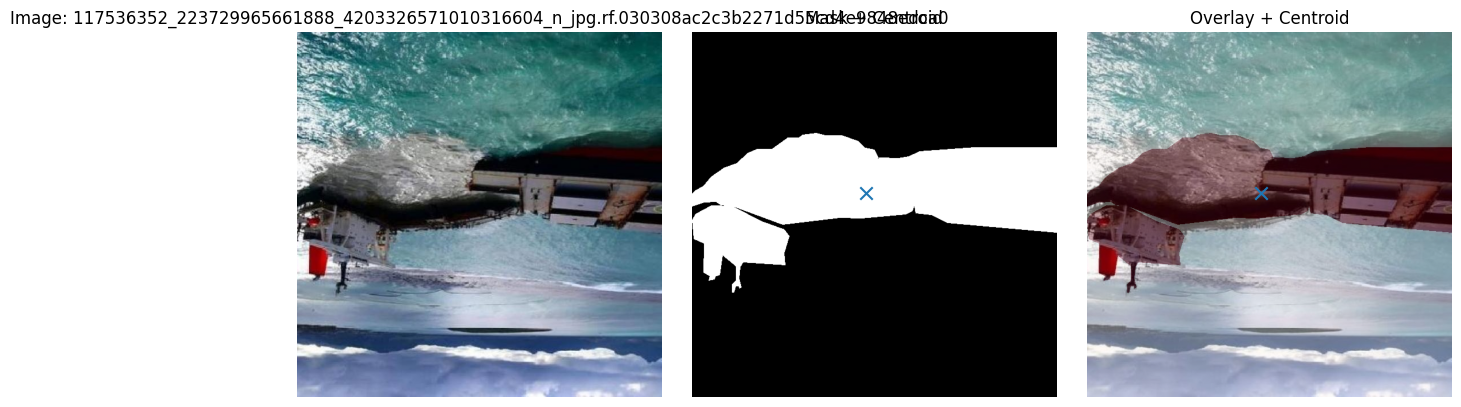

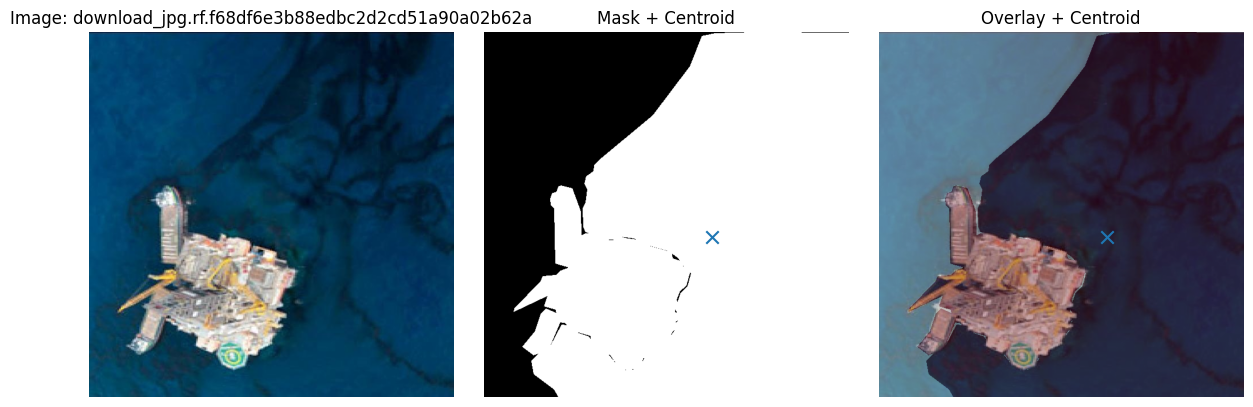

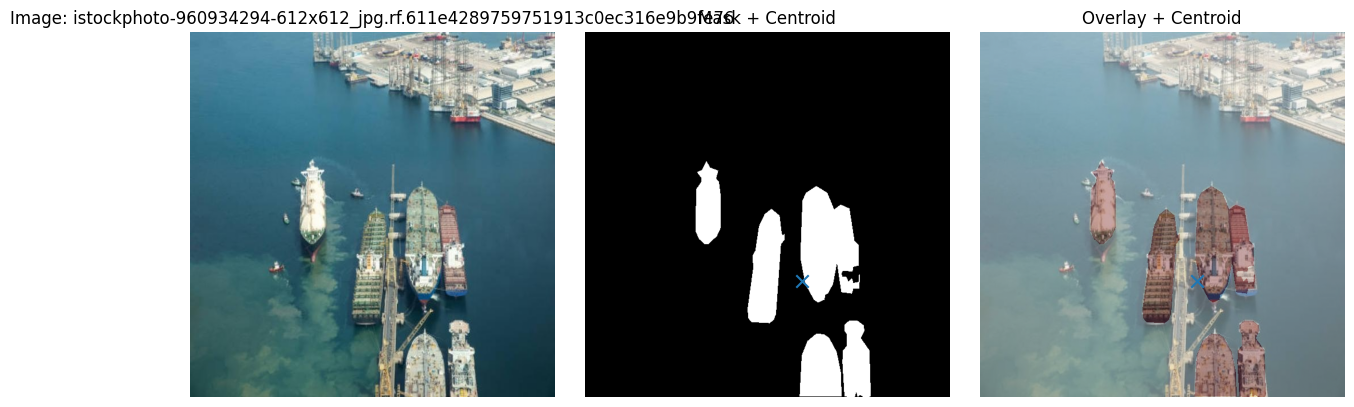

In [22]:
# ============================================================
# Step 9: Visual Check Sample Masks, Centroids, and Overlays
# ============================================================

if len(non_empty_features_df) > 0:
    sample_df = non_empty_features_df.sample(
        n=min(6, len(non_empty_features_df)),
        random_state=42
    )

    for _, row in sample_df.iterrows():
        image = Image.open(row["image_path"]).convert("RGB")
        mask = Image.open(row["mask_path"]).convert("L")

        image_np = np.array(image)
        mask_np = np.array(mask)

        plt.figure(figsize=(12, 4))

        plt.subplot(1, 3, 1)
        plt.imshow(image_np)
        plt.title(f"Image: {row['image_id']}")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(mask_np, cmap="gray")
        plt.scatter(row["centroid_x"], row["centroid_y"], marker="x", s=80)
        plt.title("Mask + Centroid")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(image_np)
        plt.imshow(mask_np, cmap="Reds", alpha=0.35)
        plt.scatter(row["centroid_x"], row["centroid_y"], marker="x", s=80)
        plt.title("Overlay + Centroid")
        plt.axis("off")

        plt.tight_layout()
        plt.show()
else:
    print("No non-empty masks available for visual check.")

In [23]:
# ============================================================
# Step 10: Save Final Extraction Summary
# ============================================================

total_samples = len(mask_features_df)
non_empty_samples = len(non_empty_features_df)
empty_samples = int(mask_features_df["is_empty_mask"].sum())

summary_md = f"""
# LADOS Mask Feature Extraction Summary

## Purpose
This notebook extracts geometric oil-spill state features from the processed LADOS segmentation masks. These extracted features are used as initial spill states for the trajectory prediction dataset.

## Input Folder
`{BEST_DETECTION_PROCESSED_DIR}`

## Output Files
- `{features_path}`
- `{non_empty_path}`
- `{summary_path}`
- `{count_path}`
- `{pairs_path}`
- `{issues_path}`
- `{area_plot_path}`
- `{centroid_plot_path}`

## Dataset Summary
- Total paired samples: {total_samples}
- Non-empty oil-spill masks: {non_empty_samples}
- Empty masks: {empty_samples}

## Extracted Features
- centroid_x
- centroid_y
- centroid_x_norm
- centroid_y_norm
- area_pixels
- area_ratio
- bbox_x_min
- bbox_y_min
- bbox_x_max
- bbox_y_max
- bbox_width
- bbox_height
- bbox_area
- bbox_area_ratio
- is_empty_mask

## Important Note
The extracted features are derived from LADOS segmentation masks. Since LADOS does not provide synchronized metocean or temporal trajectory annotations, these geometric features will be used to initialize a physics-guided synthetic trajectory dataset in the next notebook.

## Next Step
Use `trajectory_lados_non_empty_mask_features.csv` in `05_lados_initialized_trajectory_dataset_creation.ipynb`.
"""

summary_md_path = RESULT_DIR / "LADOS_MASK_FEATURE_EXTRACTION_SUMMARY.md"
summary_md_path.write_text(summary_md)

print(summary_md)
print("Saved:", summary_md_path)


# LADOS Mask Feature Extraction Summary

## Purpose
This notebook extracts geometric oil-spill state features from the processed LADOS segmentation masks. These extracted features are used as initial spill states for the trajectory prediction dataset.

## Input Folder
`/content/drive/MyDrive/Oil Spill/Best Detection Model/processed`

## Output Files
- `/content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/data/extracted/trajectory_lados_mask_features.csv`
- `/content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/data/extracted/trajectory_lados_non_empty_mask_features.csv`
- `/content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/results/lados_mask_feature_summary.csv`
- `/content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/results/processed_image_mask_count_summary.csv`
- `/content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/results/processed_image_mask_pairs.csv`
- `/content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/results/processed_pairing_issues.json`
- `/content/drive/MyDrive/Oil Spill/04

In [25]:
# ============================================================
# Step 10B: Update Final Extraction Summary with Quality Filter
# ============================================================

total_samples = len(mask_features_df)
non_empty_samples = len(non_empty_features_df)
valid_samples = len(valid_trajectory_features_df)
empty_samples = int(mask_features_df["is_empty_mask"].sum())
tiny_masks = int(quality_df["is_tiny_mask"].sum())
near_full_masks = int(quality_df["is_near_full_mask"].sum())

summary_md = f"""
# LADOS Mask Feature Extraction Summary

## Purpose
This notebook extracts geometric oil-spill state features from the processed LADOS segmentation masks. These extracted features are used as initial spill states for the trajectory prediction dataset.

## Input Folder
`{BEST_DETECTION_PROCESSED_DIR}`

## Main Output Files
- `{features_path}`
- `{non_empty_path}`
- `{valid_features_path}`
- `{summary_path}`
- `{quality_summary_path}`
- `{valid_split_summary_path}`

## Plot Files
- `{area_plot_path}`
- `{centroid_plot_path}`

## Dataset Summary
- Total paired samples: {total_samples}
- Non-empty oil-spill masks: {non_empty_samples}
- Empty masks: {empty_samples}
- Tiny masks removed: {tiny_masks}
- Near-full masks removed: {near_full_masks}
- Final valid masks for trajectory initialization: {valid_samples}

## Extracted Features
- centroid_x
- centroid_y
- centroid_x_norm
- centroid_y_norm
- area_pixels
- area_ratio
- bbox_x_min
- bbox_y_min
- bbox_x_max
- bbox_y_max
- bbox_width
- bbox_height
- bbox_area
- bbox_area_ratio
- is_empty_mask
- is_tiny_mask
- is_near_full_mask
- is_valid_for_trajectory

## Important Note
The extracted features are derived from LADOS segmentation masks. Since LADOS does not provide synchronized metocean or temporal trajectory annotations, these geometric features will be used to initialize a physics-guided synthetic trajectory dataset in the next notebook.

## Next Step
Use `trajectory_lados_valid_mask_features.csv` in `05_lados_initialized_trajectory_dataset_creation.ipynb`.
"""

summary_md_path = RESULT_DIR / "LADOS_MASK_FEATURE_EXTRACTION_SUMMARY.md"
summary_md_path.write_text(summary_md)

print(summary_md)
print("Saved:", summary_md_path)


# LADOS Mask Feature Extraction Summary

## Purpose
This notebook extracts geometric oil-spill state features from the processed LADOS segmentation masks. These extracted features are used as initial spill states for the trajectory prediction dataset.

## Input Folder
`/content/drive/MyDrive/Oil Spill/Best Detection Model/processed`

## Main Output Files
- `/content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/data/extracted/trajectory_lados_mask_features.csv`
- `/content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/data/extracted/trajectory_lados_non_empty_mask_features.csv`
- `/content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/data/extracted/trajectory_lados_valid_mask_features.csv`
- `/content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/results/lados_mask_feature_summary.csv`
- `/content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/results/lados_mask_quality_filter_summary.csv`
- `/content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/results/lados_valid_mask_split_summary.csv`

## Plot Fil

In [26]:
# ============================================================
# Final Check: Required Output Files
# ============================================================

required_files = [
    EXTRACTED_DIR / "trajectory_lados_mask_features.csv",
    EXTRACTED_DIR / "trajectory_lados_non_empty_mask_features.csv",
    RESULT_DIR / "processed_image_mask_count_summary.csv",
    RESULT_DIR / "processed_image_mask_pairs.csv",
    RESULT_DIR / "processed_pairing_issues.json",
    RESULT_DIR / "lados_mask_feature_summary.csv",
    RESULT_DIR / "LADOS_MASK_FEATURE_EXTRACTION_SUMMARY.md",
    PLOT_DIR / "lados_mask_area_distribution.png",
    PLOT_DIR / "lados_centroid_distribution.png"
]

for file_path in required_files:
    print(file_path.name, "=>", file_path.exists())

trajectory_lados_mask_features.csv => True
trajectory_lados_non_empty_mask_features.csv => True
processed_image_mask_count_summary.csv => True
processed_image_mask_pairs.csv => True
processed_pairing_issues.json => True
lados_mask_feature_summary.csv => True
LADOS_MASK_FEATURE_EXTRACTION_SUMMARY.md => True
lados_mask_area_distribution.png => True
lados_centroid_distribution.png => True
